In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Rutas
PROCESSED = '../data/processed/'
MODELS = '../models/'

# Cargamos features
df = pd.read_pickle(PROCESSED + 'df_features.pkl')

# Cargamos scaler, columnas a escalar y modelo ganador
scaler = joblib.load(MODELS + 'scaler.pkl')
cols_to_scale = joblib.load(MODELS + 'cols_to_scale.pkl')
rf_best = joblib.load(MODELS + 'random_forest.pkl')

# Separamos features y target
X = df.drop(columns=['success'])
y = df['success']

# Split estratificado — mismos parámetros que fases anteriores
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Escalado del test — fit ya está hecho en el scaler cargado
X_test_scaled = X_test.copy()
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

# Verificación
print("Modelo cargado:", type(rf_best).__name__)
print("X_test_scaled:", X_test_scaled.shape)

Modelo cargado: RandomForestClassifier
X_test_scaled: (646, 28)


In [5]:
# TreeExplainer está optimizado específicamente para modelos basados en árboles
explainer = shap.TreeExplainer(rf_best)

# Calculamos los SHAP values sobre el test
# Usamos X_test_scaled porque es lo que el modelo "ve"
shap_values = explainer.shap_values(X_test_scaled)

print("Shape de shap_values:", np.array(shap_values).shape)
print("Shape de X_test_scaled:", X_test_scaled.shape)

Shape de shap_values: (646, 28, 2)
Shape de X_test_scaled: (646, 28)


In [6]:
# Seleccionamos los SHAP values de la clase "éxito" (índice 1)
shap_values_success = shap_values[:, :, 1]

print("Shape tras seleccionar clase éxito:", shap_values_success.shape)
print("Coincide con X_test_scaled:", shap_values_success.shape == X_test_scaled.shape)

Shape tras seleccionar clase éxito: (646, 28)
Coincide con X_test_scaled: True


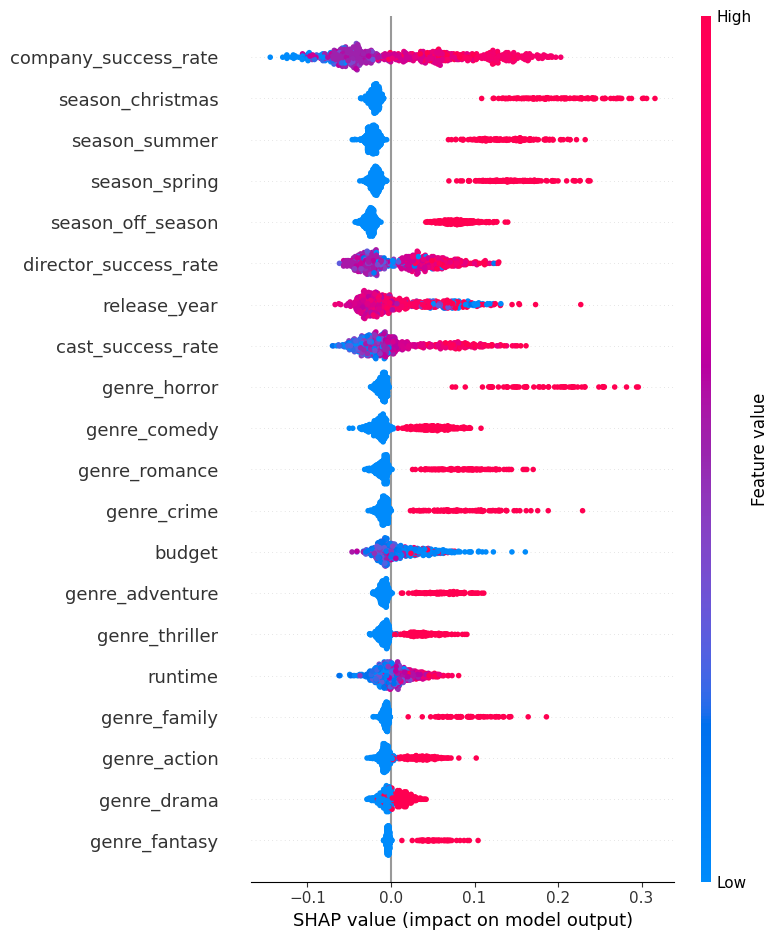

In [7]:
# Summary plot
shap.summary_plot(shap_values_success, X_test_scaled, show=False)
plt.tight_layout()
plt.savefig('../app/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

### 🔍 Interpretabilidad — Summary Plot

El factor más influyente es `company_success_rate`, con un gradiente limpio:
productoras con historial fuerte empujan claramente hacia el éxito.

Resultado inesperado: las temporadas de estreno (`season_christmas`,
`season_summer`, `season_spring`) aparecen entre los features más influyentes,
muy por encima de lo sugerido por su análisis univariante en el EDA (rango de
solo 11 puntos). Esto revela una interacción: el momento de estreno aporta
información adicional muy valiosa cuando se combina con el resto de variables
del contexto de la película.

`director_success_rate` y `cast_success_rate` tienen influencia moderada,
parcialmente solapada con `company_success_rate`.

Los géneros horror, romance, crime y comedy muestran un patrón consistente:
su presencia empuja hacia el éxito, coherente con sus altas tasas en el EDA.

`budget`, pese a ser la variable más "intuitiva", tiene de las influencias más
débiles y dispersas — confirmando la conclusión del EDA de que el presupuesto
por sí solo no discrimina bien el éxito comercial.

In [8]:
# Predicciones del modelo sobre test
y_pred_test = rf_best.predict(X_test_scaled)
y_prob_test = rf_best.predict_proba(X_test_scaled)[:, 1]

# Reseteamos índices para que coincidan con shap_values (que es un array 0-indexado)
y_test_reset = y_test.reset_index(drop=True)
y_pred_reset = pd.Series(y_pred_test)
y_prob_reset = pd.Series(y_prob_test)

# Buscamos un caso donde el modelo predijo "éxito" con alta confianza pero fue "fracaso"
errores = X_test_scaled.reset_index(drop=True)[
    (y_test_reset == 0) & (y_pred_reset == 1) & (y_prob_reset > 0.85)
]

print("Casos de error con alta confianza encontrados:", len(errores))
print("\nÍndices:", errores.index.tolist()[:5])

# Tomamos el primero
idx_caso = errores.index[0]
print(f"\nCaso elegido: índice {idx_caso}")
print(f"Predicción del modelo: {y_prob_reset[idx_caso]:.3f} (probabilidad de éxito)")
print(f"Realidad: {'Éxito' if y_test_reset[idx_caso] == 1 else 'Fracaso'}")

Casos de error con alta confianza encontrados: 3

Índices: [311, 370, 512]

Caso elegido: índice 311
Predicción del modelo: 0.885 (probabilidad de éxito)
Realidad: Fracaso


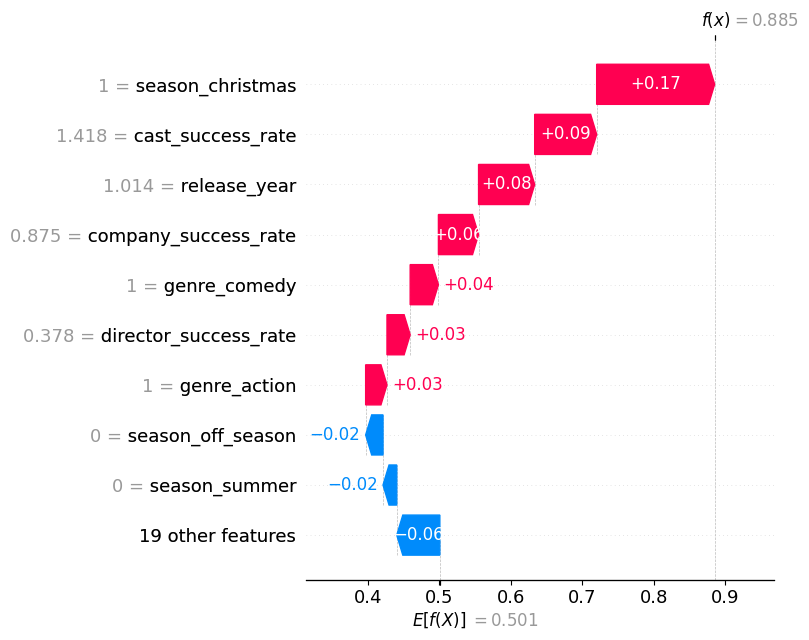

In [9]:
# Waterfall plot del caso elegido
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_success[idx_caso],
        base_values=explainer.expected_value[1],
        data=X_test_scaled.reset_index(drop=True).iloc[idx_caso].values,
        feature_names=X_test_scaled.columns.tolist()
    ),
    show=False
)
plt.tight_layout()
plt.savefig('../app/shap_waterfall_example.png', dpi=150, bbox_inches='tight')
plt.show()

### 🔍 Interpretabilidad — Caso de error individual

Analizamos un caso donde el modelo predijo 88.5% de probabilidad de éxito pero
la película resultó ser un fracaso. El waterfall revela que el modelo construyó
su predicción sobre una combinación de factores de contexto muy favorables:
estreno en temporada de Navidad (+0.17, el factor decisivo), reparto con
historial fuerte (+0.09), año reciente (+0.08) y productora sólida (+0.06).

Esto ilustra una limitación estructural del proyecto: el modelo predice en base
a *quién participa y cuándo se estrena*, pero no tiene forma de evaluar la
*calidad intrínseca* de la película — guion, dirección, ejecución — información
que por definición no existe antes del estreno. Un modelo de este tipo puede
identificar películas con "todas las condiciones para el éxito" pero no puede
predecir si la ejecución estará a la altura de esas condiciones.